In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from biom import Table, load_table
from biom.util import biom_open
from scipy.optimize import curve_fit
from scipy.stats import linregress
from skbio.stats.composition import closure

In [2]:
INPUT_DIR = Path("input_files")
OUTDIR = Path("output_files")
OUTDIR.mkdir(parents=True, exist_ok=True)

RAW_BIOM_FILE = OUTDIR / "birdman_feature_table_with_taxonomy.biom"
FILTERED_BIOM_FILE = OUTDIR / "mucus_filtered_table_with_taxonomy.biom"
FILTERED_BIOM_WITH_METADATA_FILE = OUTDIR / "mucus_filtered_table_with_sample_metadata.biom"
MODEL_METADATA_FILE = OUTDIR / "metadata_model_used_for_BIRDMAn.tsv"
DISPERSION_PRIOR_FILE = OUTDIR / "mucus_dispersion_and_inv_disp_prior.tsv"
STAN_FILE = OUTDIR / "negative_binomial_model.stan"
INFERENCE_CLR_FILE = OUTDIR / "inference.nc"
INFERENCE_LABELED_FILE = OUTDIR / "inference_ASV_annotated.nc"
LOO_COMPARISON_FILE = OUTDIR / "loo_model_comparison.tsv"

In [3]:
# Create BIOM table with taxonomy
# 1. Load OTU table (features x samples)
counts = pd.read_csv(INPUT_DIR / "birdman_otu_table.tsv", sep="\t", index_col=0)

# 2. Load full taxonomy table (rows = features/ASVs)
taxonomy = pd.read_csv(INPUT_DIR / "birdman_taxonomy.tsv", sep="\t", index_col=0)

# If 'ASV' is a column (not the index), drop it
if "ASV" in taxonomy.columns:
    taxonomy = taxonomy.drop(columns=["ASV"])

# 3. Make sure we have a single semicolon-joined taxonomy string
if "Taxonomy" not in taxonomy.columns:
    # adapt col slice if different number of ranks
    taxonomy["Taxonomy"] = taxonomy.iloc[:, 0:7].apply(
        lambda x: "; ".join(str(i) for i in x if pd.notnull(i)),
        axis=1
    )
# Keep only Taxonomy column
taxonomy = taxonomy[["Taxonomy"]]

# 4. Align taxonomy with count table by ASV IDs
taxonomy = taxonomy.reindex(counts.index)

# 5. Build observation metadata in BIOM-style:
#    {"taxonomy": ["k__Bacteria", "p__Firmicutes", ...]}
observation_metadata = []
for asv, row in taxonomy.iterrows():
    tax_str = row["Taxonomy"]

    if isinstance(tax_str, str) and tax_str.strip():
        tax_list = [t.strip() for t in tax_str.split(";") if t.strip()]
        observation_metadata.append({"taxonomy": tax_list})
    else:
        # no taxonomy available for this ASV
        observation_metadata.append(None)

# 6. Create BIOM table
biom_table = Table(
    counts.values,
    observation_ids=counts.index.astype(str),
    sample_ids=counts.columns.astype(str),
    observation_metadata=observation_metadata
)

# Save BIOM
with open(RAW_BIOM_FILE, "w") as f:
    f.write(biom_table.to_json("biom_table"))

print(f"Saved BIOM table: {RAW_BIOM_FILE.resolve()}")
print("Shape (features × samples):", biom_table.shape)


Saved BIOM table: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/birdman_feature_table_with_taxonomy.biom
Shape (features × samples): (3261, 358)


In [4]:
# Load the BIOM table just written above
# sanity check that the file is valid and taxonomy metadata are retained).
table = load_table(RAW_BIOM_FILE)

# Summarize table shape and IDs
print("✅ Format OK!")
print("Shape (features × samples):", table.shape)
print("First 5 samples:", table.ids(axis='sample')[:5])
print("First 5 features:", table.ids(axis='observation')[:5])

# Extract taxonomy metadata if available
obs_md = table.metadata(axis='observation')

if obs_md and "taxonomy" in obs_md[0]:
    print("✅ Taxonomy metadata found.")

    # Extract taxonomy into strings
    taxonomy_list = [md["taxonomy"] for md in obs_md]
    taxonomy_strs = ["; ".join(t) if isinstance(t, list) else str(t) for t in taxonomy_list]

    taxonomy_df = pd.DataFrame({
        "FeatureID": table.ids(axis='observation'),
        "Taxonomy": taxonomy_strs
    }).set_index("FeatureID")

    # Now summarize taxonomy
    print("\nTop 10 most common taxonomic assignments:")
    print(taxonomy_df["Taxonomy"].value_counts().head(10))

else:
    print("⚠️ No taxonomy metadata found.")

✅ Format OK!
Shape (features × samples): (3261, 358)
First 5 samples: ['MicrobE_1_D_P1' 'MicrobE_2_D_P1' 'MicrobE_3_D_P1' 'MicrobE_4_D_P1'
 'MicrobE_5_D_P1']
First 5 features: ['ASV_1' 'ASV_2' 'ASV_3' 'ASV_4' 'ASV_5']
✅ Taxonomy metadata found.

Top 10 most common taxonomic assignments:
Taxonomy
k__Bacteria; p__Pseudomonadota; c__Gammaproteobacteria; o__Pseudomonadales; f__Pseudomonadaceae; g__Pseudomonas; s__     88
k__Bacteria; p__Pseudomonadota; c__Gammaproteobacteria; o__Pseudomonadales; f__Moraxellaceae; g__Acinetobacter; s__      71
k__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Flavobacteriales; f__Flavobacteriaceae; g__Flavobacterium; s__          69
k__Bacteria; p__Actinomycetota; c__Actinobacteria; o__Mycobacteriales; f__Corynebacteriaceae; g__Corynebacterium; s__    58
k__Bacteria; p__Pseudomonadota; c__Gammaproteobacteria; o__Enterobacterales; f__Vibrionaceae; g__Photobacterium; s__     54
k__Bacteria; p__Bacillota; c__Bacilli; o__Mycoplasmatales; f__Mycoplasmataceae; g__

In [5]:
# Load sample metadata table
metadata = pd.read_csv(INPUT_DIR / "birdman_sample_metadata.tsv", sep="\t", index_col=0)
metadata.head()

,SampleID,sample_number,rearing_tank,sample_type,Diet,Day,sample_type_diet_day,sample_type_diet,PLSDA_Y,DNA_extraction_batch,grinding_method,PCR1_batch,PGTB_batch,Plasma_Glucose,HSI,Body_Weight,sampleID_STPN2309,Plasma_L-Lactate,Plasma_D-Lactate
Unnamed: 0,,,,,,,,,,,,,,,,,,,
MicrobE_1_D_P1,MicrobE_1_D_P1,1.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,F,Precellys,PCR1_1,P1,0.867267,0.895954,69.2,S_017,3.262599,0.038986
MicrobE_107_D_P2,MicrobE_107_D_P2,107.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,C,TissueLyser,PCR1_3,P2,0.682533,1.268437,67.8,S_023,2.552836,0.014270
MicrobE_109_D_P2,MicrobE_109_D_P2,109.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,D,Precellys,PCR1_3,P2,0.824363,0.796020,80.4,S_021,1.458673,0.020578
MicrobE_119_D_P2,MicrobE_119_D_P2,119.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,F,Precellys,PCR1_3,P2,0.595514,0.897598,79.1,S_007,NaN,0.006162
MicrobE_142_D_P2,MicrobE_142_D_P2,142.0,NaN,Digesta,Fasted,day_00,Digesta_Fasted,Digesta_Fasted,NaN,A,TissueLyser,PCR1_4,P2,0.615200,1.073620,65.2,S_005,1.866123,0.016240


In [6]:
print(set(table.ids(axis='sample')) <= set(metadata.index))

True


In [7]:
# Subset metadata where sample_type == "Mucus" and Diet is either "NC" or "HC"
metadata_model = metadata[
    (metadata["sample_type"] == "Mucus") &
    (metadata["Diet"].isin(["NC", "HC"]))
].copy()
# Check the result
print(metadata_model.shape)
metadata_model.head()

(163, 19)


,SampleID,sample_number,rearing_tank,sample_type,Diet,Day,sample_type_diet_day,sample_type_diet,PLSDA_Y,DNA_extraction_batch,grinding_method,PCR1_batch,PGTB_batch,Plasma_Glucose,HSI,Body_Weight,sampleID_STPN2309,Plasma_L-Lactate,Plasma_D-Lactate
Unnamed: 0,,,,,,,,,,,,,,,,,,,
MicrobE_185_M_P3,MicrobE_185_M_P3,185.0,K3,Mucus,HC,day_01,Mucus_HC_day1,Mucus_HC,NaN,L,Precellys,PCR1_5,P3,0.883400,0.873309,81.3,S_071,2.872659,0.046591
MicrobE_206_M_P3,MicrobE_206_M_P3,206.0,K1,Mucus,HC,day_01,Mucus_HC_day1,Mucus_HC,NaN,O,Precellys,PCR1_5,P3,2.619121,1.078562,75.1,S_051,1.918538,0.026128
MicrobE_213_M_P3,MicrobE_213_M_P3,213.0,K1,Mucus,HC,day_01,Mucus_HC_day1,Mucus_HC,NaN,O,Precellys,PCR1_5,P3,1.418167,1.410615,71.6,S_053,3.897555,0.027697
MicrobE_223_M_P3,MicrobE_223_M_P3,223.0,J5,Mucus,HC,day_01,Mucus_HC_day1,Mucus_HC,NaN,J,Precellys,PCR1_5,P3,1.592067,1.266319,76.6,S_035,3.977528,0.064335
MicrobE_224_M_P3,MicrobE_224_M_P3,224.0,J5,Mucus,HC,day_01,Mucus_HC_day1,Mucus_HC,NaN,K,Precellys,PCR1_5,P3,1.069733,0.846485,69.7,S_039,1.947614,0.013126


In [8]:
# Convert to categorical with NC as the reference level
metadata_model["Diet"] = pd.Categorical(
    metadata_model["Diet"],
    categories=["NC", "HC"],  # Explicit ref level order
    ordered=True
)

# Now you can inspect the levels
print("Diet levels:", metadata_model["Diet"].cat.categories)
print("Diet codes mapping:", dict(enumerate(metadata_model["Diet"].cat.categories)))

Diet levels: Index(['NC', 'HC'], dtype='object')
Diet codes mapping: {0: 'NC', 1: 'HC'}


In [9]:
# Convert BIOM table to DataFrame and filter samples -
raw_tbl_df = table.to_dataframe()

# Step 1: Keep only the samples present in your filtered metadata
samps_to_keep = sorted(list(set(raw_tbl_df.columns).intersection(metadata_model.index)))
filt_tbl_df = raw_tbl_df.loc[:, samps_to_keep]

# Filter ASVs present in at least 20% of retained samples
prevalence_prop = 0.20
min_prevalence = int(np.ceil(prevalence_prop * filt_tbl_df.shape[1]))

# Keep your original prevalence calculation
prev = filt_tbl_df.clip(upper=1).sum(axis=1)

filt_tbl_df = filt_tbl_df.loc[
    prev >= min_prevalence,
    :
]

filt_tbl = Table(
    filt_tbl_df.values,
    sample_ids=filt_tbl_df.columns,
    observation_ids=filt_tbl_df.index
)

print(f"Minimum prevalence: {min_prevalence} samples ({prevalence_prop:.0%})")
print(f"Maximum observed prevalence: {prev.max()}")
print("Shape (features × samples):", filt_tbl.shape)

Minimum prevalence: 33 samples (20%)
Maximum observed prevalence: 163.0
Shape (features × samples): (47, 163)


In [10]:
# Calculate mean and variance per ASV
means = filt_tbl_df.astype(float).mean(axis=1)
print(means)

ASV_48          16.331288
ASV_124         11.932515
ASV_276         12.987730
ASV_338          1.889571
ASV_347          5.104294
ASV_484        158.147239
ASV_636          5.889571
ASV_685         14.564417
ASV_718          4.895706
ASV_737         26.699387
ASV_847         16.472393
ASV_967         31.742331
ASV_1017        11.558282
ASV_1351        19.852761
ASV_1464        55.417178
ASV_1517       156.834356
ASV_1577        17.656442
ASV_1587       138.282209
ASV_1628         4.349693
ASV_1650        10.748466
ASV_1710        10.877301
ASV_1801        21.754601
ASV_1802         8.785276
ASV_1818       166.588957
ASV_1819        85.453988
ASV_1846    163470.269939
ASV_1885        34.429448
ASV_1907       217.619632
ASV_1926         4.564417
ASV_1954        17.300613
ASV_1985         5.705521
ASV_2007         4.049080
ASV_2046       121.361963
ASV_2334       136.276074
ASV_2336        55.533742
ASV_2348        14.104294
ASV_2440         8.950920
ASV_2581        18.386503
ASV_2734    

In [11]:
variances = filt_tbl_df.astype(float).var(axis=1, ddof=1)
print(variances)

ASV_48      2.754902e+03
ASV_124     6.060510e+02
ASV_276     2.117185e+03
ASV_338     1.092600e+01
ASV_347     2.114397e+02
ASV_484     6.626386e+03
ASV_636     1.509507e+02
ASV_685     4.920507e+03
ASV_718     2.602915e+02
ASV_737     5.099100e+03
ASV_847     7.726705e+02
ASV_967     1.402600e+03
ASV_1017    4.168186e+03
ASV_1351    1.276768e+03
ASV_1464    6.319948e+03
ASV_1517    6.308386e+03
ASV_1577    3.438936e+02
ASV_1587    5.112772e+03
ASV_1628    1.488214e+02
ASV_1650    5.876339e+02
ASV_1710    5.357379e+02
ASV_1801    3.927828e+03
ASV_1802    1.193071e+03
ASV_1818    6.721798e+05
ASV_1819    3.402212e+03
ASV_1846    1.688827e+09
ASV_1885    8.726686e+04
ASV_1907    1.779645e+05
ASV_1926    3.022844e+02
ASV_1954    1.276360e+03
ASV_1985    1.055918e+02
ASV_2007    1.491210e+02
ASV_2046    3.615936e+03
ASV_2334    4.685892e+03
ASV_2336    1.221937e+04
ASV_2348    2.664625e+03
ASV_2440    3.434914e+02
ASV_2581    1.398485e+03
ASV_2734    3.207073e+03
ASV_2862    3.629538e+03


In [12]:
# Calculate raw dispersion
raw_dispersion = (variances - means) / (means ** 2)
print(raw_dispersion)

ASV_48      10.267934
ASV_124      4.172622
ASV_276     12.474408
ASV_338      2.530875
ASV_347      7.919582
ASV_484      0.258620
ASV_636      4.181998
ASV_685     23.127900
ASV_718     10.655730
ASV_737      7.115592
ASV_847      2.786905
ASV_967      1.360551
ASV_1017    31.113909
ASV_1351     3.189072
ASV_1464     2.039857
ASV_1517     0.250093
ASV_1577     1.046471
ASV_1587     0.260145
ASV_1628     7.635994
ASV_1650     4.993402
ASV_1710     4.436104
ASV_1801     8.253500
ASV_1802    15.344249
ASV_1818    24.215052
ASV_1819     0.454202
ASV_1846     0.063193
ASV_1885    73.589843
ASV_1907     3.753236
ASV_1926    14.290168
ASV_1954     4.206521
ASV_1985     3.068421
ASV_2007     8.848523
ASV_2046     0.237262
ASV_2334     0.244983
ASV_2336     3.944181
ASV_2348    13.323810
ASV_2440     4.175546
ASV_2581     4.082366
ASV_2734     6.486007
ASV_2862     0.236262
ASV_2937     7.869485
ASV_2988     1.002380
ASV_3018     9.254711
ASV_3022     4.466644
ASV_3044    10.454418
ASV_3169  

In [13]:
# Fit dispersion trend curve before the mean-abundance threshold
def disp_trend(mu, a0, a1):
    return a0 + a1 / mu

valid = (means > 0) & (raw_dispersion > 0)
popt, pcov = curve_fit(
    disp_trend,
    means[valid],
    raw_dispersion[valid],
    maxfev=10000
)
print(f"Pre-threshold params: a0 = {popt[0]:.4f}, a1 = {popt[1]:.4f}")

pre_threshold_dispersion = disp_trend(means, *popt)
if (pre_threshold_dispersion <= 0).any() or (~np.isfinite(pre_threshold_dispersion)).any():
    print("Warning: the pre-threshold trend has non-positive/invalid values; it is exploratory only.")
else:
    pre_threshold_inv_disp = 1.0 / pre_threshold_dispersion
    print(pre_threshold_inv_disp.head())

Pre-threshold params: a0 = 7.7089, a1 = 4.0973
ASV_48     0.125631
ASV_124    0.124188
ASV_276    0.124620
ASV_338    0.101242
ASV_347    0.117486
dtype: float64


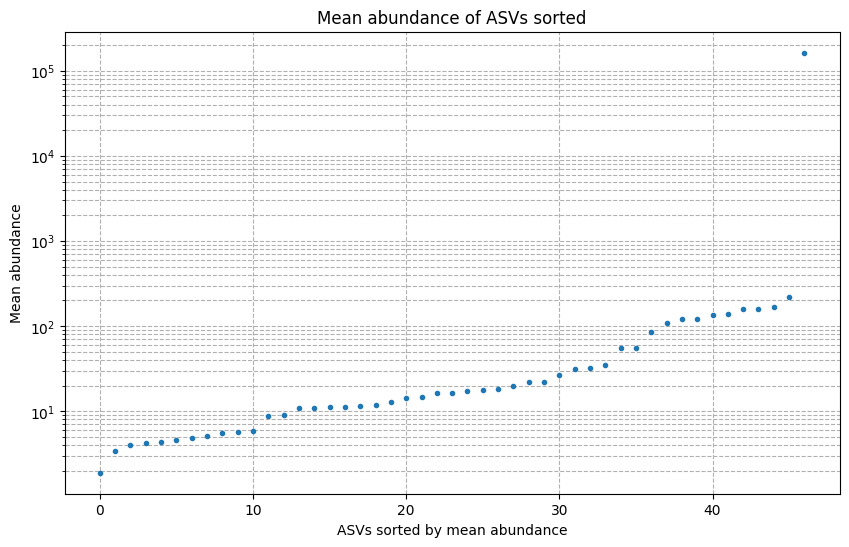

In [14]:
# --- 5. Visualize ASV mean abundances ---
sorted_means = means.sort_values()

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(sorted_means)), sorted_means, marker='.', linestyle='none')
plt.xlabel("ASVs sorted by mean abundance")
plt.ylabel("Mean abundance")
plt.title("Mean abundance of ASVs sorted")
plt.yscale("log")
plt.grid(True, which='both', linestyle='--')
plt.show()

In [15]:
# Try different filtering thresholds
thresholds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 50]
for t in thresholds:
    filtered = means[means > t]
    print(f"Threshold > {t}: {len(filtered)} ASVs retained")

Threshold > 1: 47 ASVs retained
Threshold > 2: 46 ASVs retained
Threshold > 3: 46 ASVs retained
Threshold > 4: 45 ASVs retained
Threshold > 5: 40 ASVs retained
Threshold > 6: 36 ASVs retained
Threshold > 7: 36 ASVs retained
Threshold > 8: 36 ASVs retained
Threshold > 9: 34 ASVs retained
Threshold > 10: 34 ASVs retained
Threshold > 15: 25 ASVs retained
Threshold > 20: 19 ASVs retained
Threshold > 50: 13 ASVs retained


In [16]:
# Choose a threshold and filter ASVs
threshold = 1.0
filtered_asvs = means[means > threshold]
print(f"Number of ASVs after filtering: {len(filtered_asvs)}")

# Filter filt_tbl_df to keep only ASVs above threshold
filt_tbl_df = filt_tbl_df.loc[filtered_asvs.index]

Number of ASVs after filtering: 47


In [17]:
means_f = filt_tbl_df.astype(float).mean(axis=1)
vars_f = filt_tbl_df.astype(float).var(axis=1, ddof=1)

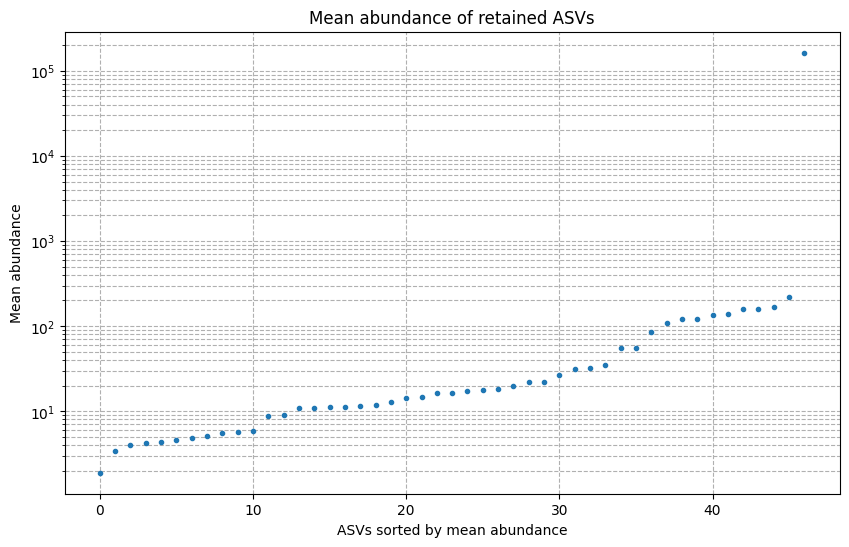

In [18]:
# Keep this second plot: it shows the retained distribution after changing `threshold`.
sorted_means = means_f.sort_values().to_numpy()

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(sorted_means)), sorted_means, marker='.', linestyle='none')
plt.xlabel("ASVs sorted by mean abundance")
plt.ylabel("Mean abundance")
plt.title("Mean abundance of retained ASVs")
plt.yscale("log")
plt.grid(True, which='both', linestyle='--')
plt.show()

In [19]:
print(sorted_means[:10])   # smallest means
print(sorted_means[-10:])  # largest means
print(np.median(sorted_means))

[1.88957055 3.36196319 4.04907975 4.26380368 4.34969325 4.56441718
 4.89570552 5.10429448 5.52760736 5.70552147]
[1.09815951e+02 1.21361963e+02 1.21846626e+02 1.36276074e+02
 1.38282209e+02 1.56834356e+02 1.58147239e+02 1.66588957e+02
 2.17619632e+02 1.63470270e+05]
16.47239263803681


In [20]:
raw_disp_f = (vars_f - means_f) / np.maximum(means_f**2, 1e-12)

In [21]:
# Fit the final DESeq2-style dispersion trend on the retained ASVs.
valid_f = (means_f > 0) & (raw_disp_f > 0)
popt_f, _ = curve_fit(
    disp_trend,
    means_f[valid_f].values,
    raw_disp_f[valid_f].values,
    maxfev=10000
)
a0_f, a1_f = popt_f
print(f"Filtered params: a0 = {a0_f:.4f}, a1 = {a1_f:.4f}")

Filtered params: a0 = 7.7089, a1 = 4.0973


In [22]:
# Final NB2 dispersion alpha and its inverse phi used by Stan.
# In neg_binomial_2_log(..., phi), Stan's second argument is phi = 1 / alpha.
smoothed_dispersion_f = a0_f + a1_f / means_f

bad_dispersion = (~np.isfinite(smoothed_dispersion_f)) | (smoothed_dispersion_f <= 0)
if bad_dispersion.any():
    bad_features = smoothed_dispersion_f.index[bad_dispersion].tolist()
    raise ValueError(
        "Final smoothed dispersion has non-positive/invalid values for "
        f"{len(bad_features)} retained ASVs. Examples: {bad_features[:10]}"
    )

inv_disp_init = 1.0 / smoothed_dispersion_f
print(inv_disp_init)

ASV_48      0.125631
ASV_124     0.124188
ASV_276     0.124620
ASV_338     0.101242
ASV_347     0.117486
ASV_484     0.129286
ASV_636     0.118983
ASV_685     0.125153
ASV_718     0.117016
ASV_737     0.127188
ASV_847     0.125665
ASV_967     0.127584
ASV_1017    0.124017
ASV_1351    0.126338
ASV_1464    0.128488
ASV_1517    0.129282
ASV_1577    0.125929
ASV_1587    0.129223
ASV_1628    0.115595
ASV_1650    0.123608
ASV_1710    0.123677
ASV_1801    0.126626
ASV_1802    0.122320
ASV_1818    0.129308
ASV_1819    0.128918
ASV_1846    0.129720
ASV_1885    0.127748
ASV_1907    0.129404
ASV_1926    0.116190
ASV_1954    0.125854
ASV_1985    0.118666
ASV_2007    0.114668
ASV_2046    0.129154
ASV_2334    0.129216
ASV_2336    0.128490
ASV_2348    0.125009
ASV_2440    0.122449
ASV_2581    0.126076
ASV_2734    0.126682
ASV_2862    0.129157
ASV_2937    0.115342
ASV_2988    0.129095
ASV_3018    0.118341
ASV_3022    0.123884
ASV_3044    0.123847
ASV_3169    0.112012
ASV_3234    0.127527
dtype: float6

In [23]:
# Keep taxonomy metadata for exactly the filtered ASVs, in exactly their final order.
obs_md = table.metadata(axis="observation")
tax_metadata_dict = {
    feature_id: metadata
    for feature_id, metadata in zip(table.ids(axis="observation"), obs_md)
}

filtered_feature_ids = filt_tbl_df.index.tolist()
filtered_tax_metadata = [tax_metadata_dict[feature_id] for feature_id in filtered_feature_ids]

filt_tbl = Table(
    filt_tbl_df.values,
    sample_ids=filt_tbl_df.columns.tolist(),
    observation_ids=filtered_feature_ids,
    observation_metadata=filtered_tax_metadata
)
print("Shape (features × samples):", filt_tbl.shape)

Shape (features × samples): (47, 163)


In [24]:
import numpy as np
import pandas as pd

counts = np.asarray(filt_tbl.matrix_data.todense())  # ASVs × samples
asv_ids = np.asarray(filt_tbl.ids(axis="observation"))

lib_size = counts.sum(axis=0)
rel_abund = counts / lib_size

stats = pd.DataFrame({
    "ASV": asv_ids,
    "prevalence_pct": 100 * (counts > 0).mean(axis=1),
    "median_count": np.median(counts, axis=1),
    "mean_rel_abund": rel_abund.mean(axis=1),
    "sd_rel_abund": rel_abund.std(axis=1),
})

stats["cv_rel_abund"] = (
    stats["sd_rel_abund"] / stats["mean_rel_abund"]
)

candidates = (
    stats
    .query("prevalence_pct >= 90 and median_count > 0")
    .sort_values(
        ["prevalence_pct", "cv_rel_abund", "mean_rel_abund"],
        ascending=[False, True, False]
    )
)

display(candidates.head(10))

,ASV,prevalence_pct,median_count,mean_rel_abund,sd_rel_abund,cv_rel_abund
25,ASV_1846,100.000000,161933.0,0.988077,0.007437,0.007527
39,ASV_2862,100.000000,107.0,0.000732,0.000289,0.394303
32,ASV_2046,100.000000,105.0,0.000736,0.000305,0.414540
15,ASV_1517,100.000000,137.0,0.000947,0.000396,0.418033
33,ASV_2334,100.000000,118.0,0.000824,0.000344,0.418120
17,ASV_1587,100.000000,121.0,0.000840,0.000373,0.444346
5,ASV_484,100.000000,141.0,0.000961,0.000433,0.451012
24,ASV_1819,100.000000,76.0,0.000501,0.000255,0.509796
27,ASV_1907,100.000000,114.0,0.001382,0.002684,1.941949
41,ASV_2988,99.386503,83.0,0.000675,0.000791,1.170870


In [25]:
# Choose the ALR reference ASV: it must be first in the BIOM observation order
reference_asv = "ASV_1846"

if reference_asv not in filt_tbl_df.index:
    raise ValueError(
        f"{reference_asv} is not present in the filtered ASV table."
    )

# Put the chosen reference first; retain the existing order for every other ASV
filtered_feature_ids = (
    [reference_asv] +
    [asv for asv in filt_tbl_df.index if asv != reference_asv]
)

# Reorder count table rows to match the intended ALR reference/order
filt_tbl_df = filt_tbl_df.loc[filtered_feature_ids]

# Keep taxonomy metadata aligned with the reordered ASVs
obs_md = table.metadata(axis="observation")
tax_metadata_dict = {
    feature_id: metadata
    for feature_id, metadata in zip(table.ids(axis="observation"), obs_md)
}

filtered_tax_metadata = [
    tax_metadata_dict[feature_id]
    for feature_id in filtered_feature_ids
]

# Construct filtered BIOM table: features × samples
filt_tbl = Table(
    filt_tbl_df.values,
    sample_ids=filt_tbl_df.columns.tolist(),
    observation_ids=filtered_feature_ids,
    observation_metadata=filtered_tax_metadata
)

assert filt_tbl.ids(axis="observation")[0] == reference_asv
assert filt_tbl.shape == filt_tbl_df.shape

print("Shape (features × samples):", filt_tbl.shape)
print("ALR reference ASV:", filt_tbl.ids(axis="observation")[0])

Shape (features × samples): (47, 163)
ALR reference ASV: ASV_1846


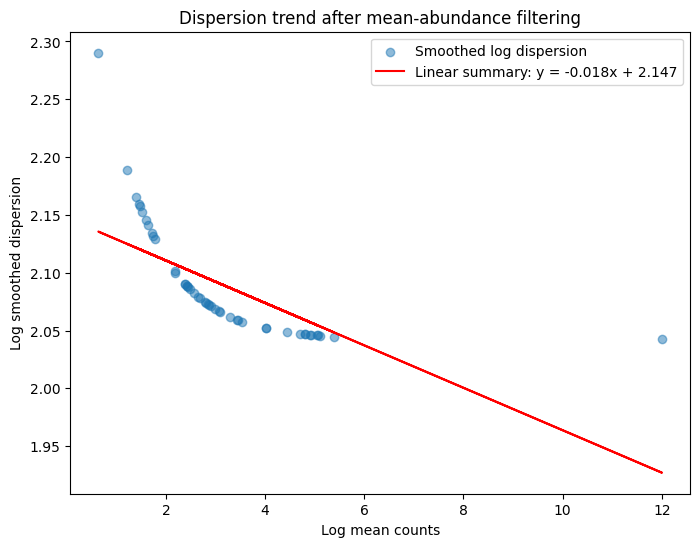

In [26]:
# Exploratory diagnostic retained from the original notebook.
log_means = np.log(means_f)
log_disp = np.log(smoothed_dispersion_f)

slope, intercept, r_value, p_value, std_err = linregress(log_means, log_disp)

plt.figure(figsize=(8, 6))
plt.scatter(log_means, log_disp, alpha=0.5, label="Smoothed log dispersion")
plt.plot(
    log_means,
    intercept + slope * log_means,
    color="red",
    label=f"Linear summary: y = {slope:.3f}x + {intercept:.3f}"
)
plt.xlabel("Log mean counts")
plt.ylabel("Log smoothed dispersion")
plt.title("Dispersion trend after mean-abundance filtering")
plt.legend()
plt.show()


Empirical mean (for prior): -4.995231833997484
Empirical std  (for prior): 1.0250542607964146


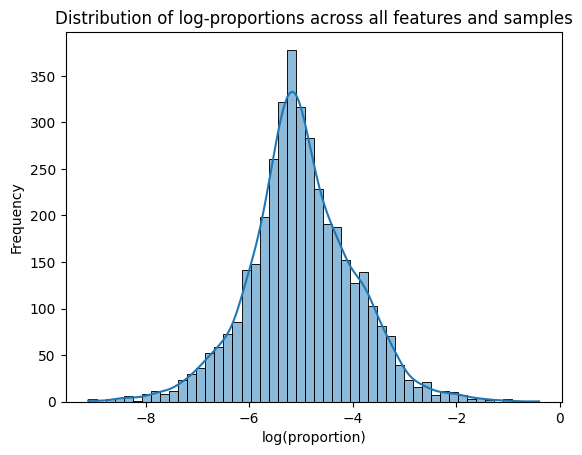

In [27]:
# pulling out any random amplicon biom table and visualizing the stats
# Namely, we can look at all of the non-zero counts, compute their log proportions and visualize the distribution
# Convert to dense NumPy array
mat = np.array(filt_tbl.matrix_data.todense())

# Apply closure to convert counts to proportions
prop_mat = closure(mat)  # Each row sums to 1

# Take the log of the proportions (masking zeros automatically)
log_prop = np.ma.log(prop_mat)  # log proportions

# Flatten and remove masked (zero) values
data = log_prop.ravel()
data = data[~data.mask]

# View stats of log-proportions
print("Empirical mean (for prior):", data.mean())
print("Empirical std  (for prior):", data.std())

# Visualize the distribution
sns.histplot(data, bins=50, kde=True)
plt.title("Distribution of log-proportions across all features and samples")
plt.xlabel("log(proportion)")
plt.ylabel("Frequency")
plt.show()

In [28]:
# We found similar results (see https://github.com/flatironinstitute/q2-matchmaker/issues/24), so we will set the same values for the model

In [29]:
with biom_open(FILTERED_BIOM_FILE, "w") as f:
    filt_tbl.to_hdf5(f, "filtered mucus table with taxonomy")

print(f"Saved filtered BIOM table: {FILTERED_BIOM_FILE.resolve()}")

Saved filtered BIOM table: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/mucus_filtered_table_with_taxonomy.biom


In [30]:
print("ASV table samples:", filt_tbl_df.shape[1])
print("Metadata samples:", metadata_model.shape[0])

print("Samples in ASV table missing from metadata:")
print(set(filt_tbl_df.columns) - set(metadata_model.index))

print("Metadata samples missing from ASV table:")
print(set(metadata_model.index) - set(filt_tbl_df.columns))


ASV table samples: 163
Metadata samples: 163
Samples in ASV table missing from metadata:
set()
Metadata samples missing from ASV table:
set()


In [31]:
metadata_model = metadata_model.loc[filt_tbl_df.columns]

assert list(metadata_model.index) == list(filt_tbl_df.columns)

print("Metadata correctly matched to ASV table.")

Metadata correctly matched to ASV table.


In [32]:
metadata_model.to_csv(
    MODEL_METADATA_FILE,
    sep="\t",
    index=True
)
print(f"Saved model metadata: {MODEL_METADATA_FILE.resolve()}")


Saved model metadata: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/metadata_model_used_for_BIRDMAn.tsv


In [33]:
sample_metadata = metadata_model.to_dict(orient="records")

filt_tbl = Table(
    filt_tbl_df.values,
    sample_ids=filt_tbl_df.columns.tolist(),
    observation_ids=filt_tbl_df.index.tolist(),
    observation_metadata=filtered_tax_metadata,
    sample_metadata=sample_metadata
)

with biom_open(FILTERED_BIOM_WITH_METADATA_FILE, "w") as f:
    filt_tbl.to_hdf5(f, "filtered mucus table with taxonomy and sample metadata")

print(f"Saved filtered BIOM table with sample metadata: {FILTERED_BIOM_WITH_METADATA_FILE.resolve()}")

Saved filtered BIOM table with sample metadata: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/mucus_filtered_table_with_sample_metadata.biom


In [34]:
bt = load_table(FILTERED_BIOM_WITH_METADATA_FILE)

print(bt.shape)

print("First ASV metadata:")
print(bt.metadata(bt.ids(axis="observation")[0], axis="observation"))

print("First sample metadata:")
print(bt.metadata(bt.ids(axis="sample")[0], axis="sample"))

(47, 163)
First ASV metadata:
defaultdict(<function Table._cast_metadata.<locals>.cast_metadata.<locals>.<lambda> at 0x7fb6277fcf40>, {'taxonomy': ['k__Bacteria', 'p__Bacillota', 'c__Bacilli', 'o__Mycoplasmatales', 'f__Mycoplasmataceae', 'g__Malacoplasma', 's__']})
First sample metadata:
defaultdict(<function Table._cast_metadata.<locals>.cast_metadata.<locals>.<lambda> at 0x7fb626759300>, {'Body_Weight': np.float64(89.0), 'DNA_extraction_batch': 'O', 'Day': 'day_04', 'Diet': 'HC', 'HSI': np.float64(2.112359551), 'PCR1_batch': 'PCR1_5', 'PGTB_batch': 'P3', 'PLSDA_Y': np.float64(nan), 'Plasma_D-Lactate': np.float64(0.027697442), 'Plasma_Glucose': np.float64(2.7938), 'Plasma_L-Lactate': np.float64(4.095459837), 'SampleID': 'MicrobE_181_M_P3', 'grinding_method': 'Precellys', 'rearing_tank': 'K1', 'sampleID_STPN2309': 'S_197', 'sample_number': np.float64(181.0), 'sample_type': 'Mucus', 'sample_type_diet': 'Mucus_HC', 'sample_type_diet_day': 'Mucus_HC_day4'})


In [35]:
# Save the Stan code to a file. `nb_model.compile_model()` below performs compilation.
stan_code = """
data {
  int<lower=1> N;                    // number of samples
  int<lower=2> D;                    // number of features
  real A;                            // intercept prior mean
  int<lower=1> p;                    // number of covariates
  vector[N] depth;                   // log sequencing depths
  matrix[N, p] x;                    // covariate matrix
  array[N, D] int<lower=0> y;        // observed counts

  real<lower=0> B_p;                 // slope prior SD
  real<lower=0> beta_0_sd;           // intercept prior SD

  // Prior centre for NB2 precision phi = 1 / alpha
  vector<lower=1e-8>[D] inv_disp_prior;
  real<lower=0> inv_disp_sd;
}

parameters {
  row_vector[D - 1] beta_0;
  matrix[p - 1, D - 1] beta_x;
  vector<lower=1e-8>[D] inv_disp;
}

transformed parameters {
  matrix[p, D - 1] beta_var = append_row(beta_0, beta_x);
  matrix[N, D - 1] lam;
  matrix[N, D] lam_clr;

  // Linear predictor for the D - 1 non-reference ASVs
  lam = x * beta_var;

  // Insert zero ALR coordinate for the first/reference ASV
  lam_clr = append_col(
    to_vector(rep_array(0, N)),
    lam
  );
}

model {
  // Intercept prior
  beta_0 ~ normal(A, beta_0_sd);

  // Diet, day, and diet × day effects
  to_vector(beta_x) ~ normal(0, B_p);

  // Feature-specific empirical prior for NB2 precision phi
  inv_disp ~ lognormal(log(inv_disp_prior), inv_disp_sd);

  // Apply sequencing-depth offset to ALL D ASVs,
  // including the first/reference ASV
  for (n in 1:N) {
    for (i in 1:D) {
      target += neg_binomial_2_log_lpmf(
        y[n, i] | lam_clr[n, i] + depth[n], inv_disp[i]
      );
    }
  }
}

generated quantities {
  array[N, D] int y_predict;
  array[N, D] real log_lhood;

  for (n in 1:N) {
    for (i in 1:D) {
      real eta = lam_clr[n, i] + depth[n];
      real safe_eta = fmin(eta, 13.8);

      y_predict[n, i] =
        neg_binomial_2_log_rng(safe_eta, inv_disp[i]);

      log_lhood[n, i] =
        neg_binomial_2_log_lpmf(
          y[n, i] | eta, inv_disp[i]
        );
    }
  }
}
"""

stan_filename = str(STAN_FILE)

with open(stan_filename, "w", encoding="utf-8") as f:
    f.write(stan_code)

print(f"Stan model saved to: {STAN_FILE.resolve()}")

Stan model saved to: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/negative_binomial_model.stan


In [36]:
import birdman
nb_model = birdman.TableModel(
    table=filt_tbl,
    model_path=stan_filename
)

In [37]:
# Step 2: Create the regression with your formula and metadata
nb_model.create_regression(
    metadata=metadata_model,  # your sample metadata
    formula="Diet * Day"
)

In [38]:
# Align the final inverse-dispersion vector to BIRDMAn's feature order.
# `inv_disp_init` is Stan's NB2 precision phi = 1 / alpha, not alpha itself.
inv_disp_prior = inv_disp_init.reindex(nb_model.feature_names)

if inv_disp_prior.isna().any():
    missing = inv_disp_prior.index[inv_disp_prior.isna()].tolist()
    raise ValueError(
        f"Missing inverse-dispersion values for {len(missing)} features. "
        f"Examples: {missing[:10]}"
    )

if (~np.isfinite(inv_disp_prior)).any() or (inv_disp_prior <= 0).any():
    bad = inv_disp_prior.index[
        (~np.isfinite(inv_disp_prior)) | (inv_disp_prior <= 0)
    ].tolist()
    raise ValueError(
        f"Inverse-dispersion prior has non-positive/invalid values for {len(bad)} features. "
        f"Examples: {bad[:10]}"
    )

# Save the exact alpha and phi values used for the final model.
prior_table = pd.DataFrame({
    "mean_count": means_f.reindex(nb_model.feature_names),
    "raw_dispersion_alpha": raw_disp_f.reindex(nb_model.feature_names),
    "smoothed_dispersion_alpha": smoothed_dispersion_f.reindex(nb_model.feature_names),
    "inv_disp_phi": inv_disp_prior,
})
prior_table.to_csv(DISPERSION_PRIOR_FILE, sep="\t", index_label="ASV")

print(
    "Inverse-dispersion prior (phi) range: "
    f"{inv_disp_prior.min():.4f} to {inv_disp_prior.max():.4f}"
)
print(f"Saved dispersion prior table: {DISPERSION_PRIOR_FILE.resolve()}")

# Convert only after all labels and values have been checked.
inv_disp_prior = inv_disp_prior.to_numpy(dtype=float)



Inverse-dispersion prior (phi) range: 0.1012 to 0.1297
Saved dispersion prior table: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/mucus_dispersion_and_inv_disp_prior.tsv


In [39]:
# sanity check before compiling and fit the model
print("Reference ASV:", filt_tbl.ids(axis="observation")[0])
print("First model feature:", nb_model.feature_names[0])
print("Phi assigned to first model feature:", inv_disp_prior[0])

Reference ASV: ASV_1846
First model feature: ASV_1846
Phi assigned to first model feature: 0.12971967899741912


In [40]:
param_dict = {
    "depth": np.log(filt_tbl.sum(axis="sample")),

    "A": -5.5, # see https://github.com/flatironinstitute/q2-matchmaker/issues/24
    "beta_0_sd": 1.5, # see https://github.com/flatironinstitute/q2-matchmaker/issues/24
    "B_p": 3, #as tutorial

    # NB2 precision phi = 1 / alpha, aligned to nb_model.feature_names.
    "inv_disp_prior": inv_disp_prior,
    "inv_disp_sd": 3, # as tutorial
}
nb_model.add_parameters(param_dict)

In [41]:
nb_model.specify_model(
    params=["beta_var", "inv_disp"],
    dims={
        "beta_var": ["covariate", "feature_alr"],
        "inv_disp": ["feature"],
        "log_lhood": ["tbl_sample", "feature"],
        "y_predict": ["tbl_sample", "feature"],
    },
    coords={
        "feature": nb_model.feature_names,
        "feature_alr": nb_model.feature_names[1:],
        "covariate": nb_model.colnames,
        "tbl_sample": nb_model.sample_names,
    },
    posterior_predictive="y_predict",
    log_likelihood="log_lhood",
    include_observed_data=True,
)


In [42]:
# Compile the model
nb_model.compile_model()

08:51:44 - cmdstanpy - INFO - compiling stan file /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/negative_binomial_model.stan to exe file /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/negative_binomial_model
08:52:12 - cmdstanpy - INFO - compiled model executable: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/negative_binomial_model


In [43]:
fit = nb_model.fit_model(
    method="mcmc",
    num_draws=500,
    mcmc_warmup=500,
    mcmc_chains=4,
    mcmc_kwargs={"show_console": True},
    seed=42,
)

08:54:49 - cmdstanpy - INFO - Chain [1] start processing
08:54:49 - cmdstanpy - INFO - Chain [2] start processing
08:54:49 - cmdstanpy - INFO - Chain [3] start processing
08:54:49 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 500
Chain [2] num_warmup = 500
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Chain [2] metric = diag_e (Default)
Chain [2] metric_file =  (Default)
Chain [2] stepsize = 1 (Default)
Chain [2] stepsize_jitter = 0 (Default)
Chain [2] num_chains = 1 (Default)
Chain [2] id = 2
Chain [2] data
Chain [2] file = /tmp/tmpi8cx_fig/pahrfqn9.json
Chain [2] init = 2 (Default)
Chain [2] random
Chain [2] seed = 42
Chain 

08:56:28 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 65.077 seconds (Warm-up)
Chain [3] 34.305 seconds (Sampling)
Chain [3] 99.382 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 


08:56:30 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 66.769 seconds (Warm-up)
Chain [1] 34.123 seconds (Sampling)
Chain [1] 100.892 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chai

08:56:30 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 67.548 seconds (Warm-up)
Chain [4] 33.569 seconds (Sampling)
Chain [4] 101.117 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chai

08:56:41 - cmdstanpy - INFO - Chain [2] done processing
08:56:41 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)


Chain [2] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 68.274 seconds (Warm-up)
Chain [2] 44.239 seconds (Sampling)
Chain [2] 112.513 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chai

In [45]:
inference = nb_model.to_inference()

In [46]:
# sanity check
ref_asv = "ASV_1846"

obs_ref = (
    inference.observed_data["observed"]
    .sel(feature=ref_asv)
    .mean()
)

pred_ref = (
    inference.posterior_predictive["y_predict"]
    .sel(feature=ref_asv)
    .mean(dim=("chain", "draw", "tbl_sample"))
)

print("Observed mean:", float(obs_ref))
print("Predicted mean:", float(pred_ref))
print("Predicted / observed:", float(pred_ref / obs_ref))

Observed mean: 163470.2699386503
Predicted mean: 165442.6847208589
Predicted / observed: 1.0120658929782695


In [47]:
# Run immediately AFTER creating inference and BEFORE transformation to check the dimension (should be n(ASVs) - 1, i.e., 139 ASVs)
posterior_alr = inference.posterior.copy(deep=True)
beta_alr = posterior_alr["beta_var"]

n_asvs = len(filt_tbl.ids("observation"))

print("Raw beta_var dimensions:", beta_alr.dims)
print("Raw beta_var sizes:", dict(beta_alr.sizes))

assert "feature_alr" in beta_alr.dims
assert beta_alr.sizes["feature_alr"] == n_asvs - 1   # 139

Raw beta_var dimensions: ('chain', 'draw', 'covariate', 'feature_alr')
Raw beta_var sizes: {'chain': 4, 'draw': 500, 'covariate': 14, 'feature_alr': 46}


In [48]:
import xarray as xr

def posterior_alr_to_clr_nd(posterior: xr.Dataset,
                            alr_params,
                            alr_dim="feature_alr",
                            clr_dim="feature",
                            new_labels=None) -> xr.Dataset:
    post = posterior.copy()

    for p in alr_params:
        if p not in post:
            continue
        da = post[p]
        if alr_dim not in da.dims:
            continue

        # 1) make a zero baseline slice with same dims except alr_dim=1
        zero = (da.isel({alr_dim: slice(0, 1)}) * 0)

        # 2) concat baseline + ALR **along the existing ALR dim**
        da_ext = xr.concat([zero, da], dim=alr_dim)  # length now D

        # 3) rename ALR dim -> CLR dim
        da_ext = da_ext.rename({alr_dim: clr_dim})

        # 4) center along CLR dim
        da_clr = da_ext - da_ext.mean(dim=clr_dim)

        # 5) attach labels if provided (length D)
        if new_labels is not None:
            da_clr = da_clr.assign_coords({clr_dim: new_labels})

        # 6) put CLR dim last (or keep your preferred order)
        new_order = [d for d in da_clr.dims if d != clr_dim] + [clr_dim]
        post[p] = da_clr.transpose(*new_order)

    # optional: drop leftover coord for ALR dim if it exists as a coord (not a dim anymore)
    if alr_dim in post.coords:
        post = post.drop_vars(alr_dim)

    return post


In [49]:
labels = nb_model.feature_names  # D labels incl. baseline
inference.posterior = posterior_alr_to_clr_nd(
    inference.posterior,
    alr_params=["beta_var"],
    alr_dim="feature_alr",
    clr_dim="feature",
    new_labels=labels,
)

In [50]:
# View summary
import arviz as az
az.summary(inference, var_names=["beta_var"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta_var[Intercept, ASV_1846]",7.878,0.101,7.684,8.059,0.002,0.002,2498.0,1212.0,1.01
"beta_var[Intercept, ASV_48]",-0.319,0.971,-2.009,1.601,0.020,0.018,2323.0,1746.0,1.00
"beta_var[Intercept, ASV_124]",0.000,0.957,-1.752,1.826,0.018,0.026,2756.0,1231.0,1.01
"beta_var[Intercept, ASV_276]",0.570,0.926,-1.188,2.320,0.019,0.020,2510.0,1685.0,1.00
"beta_var[Intercept, ASV_338]",-2.688,0.703,-3.905,-1.337,0.017,0.016,1775.0,1496.0,1.00
...,...,...,...,...,...,...,...,...,...
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3018]",-3.469,2.311,-7.485,1.059,0.043,0.055,2900.0,1407.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3022]",-0.757,1.808,-4.444,2.378,0.033,0.035,3062.0,1622.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3044]",0.898,1.398,-1.635,3.535,0.028,0.027,2485.0,1833.0,1.00
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3169]",0.089,1.920,-3.628,3.556,0.034,0.043,3197.0,1529.0,1.00


In [51]:
import birdman.diagnostics

In [52]:
birdman.diagnostics.ess(inference)

<xarray.Dataset> Size: 7kB
Dimensions:    (covariate: 14, feature: 47)
Coordinates:
  * covariate  (covariate) object 112B 'Intercept' ... 'Diet[T.HC]:Day[T.day_...
  * feature    (feature) <U8 2kB 'ASV_1846' 'ASV_48' ... 'ASV_3169' 'ASV_3234'
Data variables:
    beta_var   (covariate, feature) float64 5kB 2.498e+03 ... 1.943e+03
    inv_disp   (feature) float64 376B 3.041e+03 2.676e+03 ... 3.105e+03

In [53]:
birdman.diagnostics.r2_score(inference)

r2        0.991207
r2_std    0.039584
dtype: float64

In [54]:
birdman.diagnostics.rhat(inference)

<xarray.Dataset> Size: 7kB
Dimensions:    (covariate: 14, feature: 47)
Coordinates:
  * covariate  (covariate) object 112B 'Intercept' ... 'Diet[T.HC]:Day[T.day_...
  * feature    (feature) <U8 2kB 'ASV_1846' 'ASV_48' ... 'ASV_3169' 'ASV_3234'
Data variables:
    beta_var   (covariate, feature) float64 5kB 1.006 1.002 1.01 ... 1.0 0.9996
    inv_disp   (feature) float64 376B 0.9994 1.0 1.001 ... 1.0 1.001 1.001

<Axes: xlabel='Table Entry', ylabel='Count'>

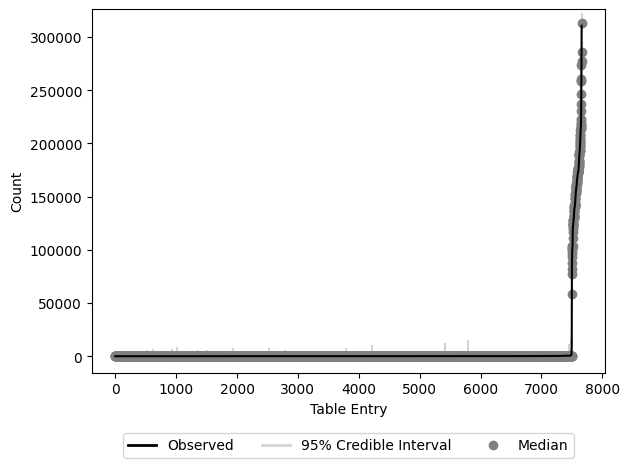

In [55]:
from birdman.visualization import plot_posterior_predictive_checks
plot_posterior_predictive_checks(inference)

In [56]:
from birdman.diagnostics import loo
loo(inference, pointwise=True)

/home/smeschini/miniconda3/envs/birdman_py311/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 2000 posterior samples and 7661 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -24083.46   251.33
p_loo      413.96        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     7563   98.7%
   (0.70, 1]   (bad)        88    1.1%
   (1, Inf)   (very bad)   10    0.1%

In [69]:
import arviz as az

loo_result = az.loo(
    inference,
    var_name="log_lhood",
    pointwise=True
)

D = len(nb_model.feature_names)
P = len(nb_model.colnames)

# Regression coefficients for D - 1 ALR features
# plus one NB2 precision parameter for each of the D features
p_nominal = P * (D - 1) + D

p_loo = float(loo_result.p_loo)

print("D features:", D)
print("Design columns P:", P)
print("Nominal parameter count p:", p_nominal)
print("p_loo:", p_loo)
print("p_loo / p:", p_loo / p_nominal)

/home/smeschini/miniconda3/envs/birdman_py311/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


D features: 47
Design columns P: 14
Nominal parameter count p: 691
p_loo: 413.9591943688756
p_loo / p: 0.599072640186506


In [63]:
import birdman
import arviz as az
import numpy as np

# Keep the fitted Diet × Day model
model_1 = inference

# -----------------------------
# Null model: intercept only
# -----------------------------
null_model = birdman.TableModel(
    table=filt_tbl,
    model_path=stan_filename
)

null_model.create_regression(
    metadata=metadata_model,
    formula="1"
)

# Same samples/features/order must be used
assert np.array_equal(null_model.sample_names, nb_model.sample_names)
assert np.array_equal(null_model.feature_names, nb_model.feature_names)

# Same priors and offset as the Diet × Day model
null_model.add_parameters(param_dict)

null_model.specify_model(
    params=["beta_var", "inv_disp"],
    dims={
        "beta_var": ["covariate", "feature_alr"],
        "inv_disp": ["feature"],
        "log_lhood": ["tbl_sample", "feature"],
        "y_predict": ["tbl_sample", "feature"],
    },
    coords={
        "covariate": null_model.colnames,
        "feature_alr": null_model.feature_names[1:],
        "feature": null_model.feature_names,
        "tbl_sample": null_model.sample_names,
    },
    posterior_predictive="y_predict",
    log_likelihood="log_lhood",
    include_observed_data=True,
)

null_model.compile_model()

null_fit = null_model.fit_model(
    method="mcmc",
    num_draws=500,
    mcmc_warmup=500,
    mcmc_chains=4,
    mcmc_kwargs={"show_console": True},
    seed=43,
)

model_0 = null_model.to_inference()

09:11:39 - cmdstanpy - INFO - Chain [1] start processing
09:11:39 - cmdstanpy - INFO - Chain [2] start processing
09:11:39 - cmdstanpy - INFO - Chain [3] start processing
09:11:39 - cmdstanpy - INFO - Chain [4] start processing


Chain [3] method = sample (Default)
Chain [3] sample
Chain [3] num_samples = 500
Chain [3] num_warmup = 500
Chain [3] save_warmup = false (Default)
Chain [3] thin = 1 (Default)
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 500
Chain [1] num_warmup = 500
Chain [1] save_warmup = false (Default)
Chain [3] adapt
Chain [3] engaged = true (Default)
Chain [3] gamma = 0.05 (Default)
Chain [3] delta = 0.8 (Default)
Chain [3] kappa = 0.75 (Default)
Chain [3] t0 = 10 (Default)
Chain [3] init_buffer = 75 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [3] term_buffer = 50 (Default)
Chain [3] window = 25 (Default)
Chain [3] save_metric = false (Default)
Chain [3] algorithm = hmc (Default)
Chain [3] hmc
Chain [3] engine = nuts (Default)
Chain [3] nuts
Chain [3] max_depth = 10 (Default)
Chain [3] metric = diag_e (Default)
Chain [3] metric_file =  (Default)
Chain [3] stepsize = 1 (Default)
Chain [3] stepsize_jitter = 0 (Default)
Chain [3] num_chains = 1 (Def

09:11:55 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 8.213 seconds (Warm-up)
Chain [3] 7.497 seconds (Sampling)
Chain [3] 15.71 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3

09:11:56 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 9.032 seconds (Warm-up)
Chain [1] 7.702 seconds (Sampling)
Chain [1] 16.734 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [

09:11:58 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 8.657 seconds (Warm-up)
Chain [2] 9.215 seconds (Sampling)
Chain [2] 17.872 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [

09:11:58 - cmdstanpy - INFO - Chain [4] done processing
09:11:58 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)
Exception: neg_binomial_2_log_lpmf: Precision parameter is inf, but must be positive finite! (in 'negative_binomial_model.stan', line 54, column 6 to line 56, column 8)


Chain [4] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 8.844 seconds (Warm-up)
Chain [4] 9.641 seconds (Sampling)
Chain [4] 18.485 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [

In [64]:
comparison = az.compare(
    {
        "null": model_0,
        "Diet_x_Day": model_1,
    },
    ic="loo"
)

print(comparison)
comparison.to_csv(LOO_COMPARISON_FILE, sep="\t")
print(f"Saved LOO comparison: {LOO_COMPARISON_FILE.resolve()}")

/home/smeschini/miniconda3/envs/birdman_py311/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/smeschini/miniconda3/envs/birdman_py311/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


            rank      elpd_loo       p_loo  elpd_diff    weight          se  \
null           0 -24051.859139  105.629404   0.000000  0.572803  251.654531   
Diet_x_Day     1 -24083.460881  413.959194  31.601742  0.427197  251.334312   

                  dse  warning scale  
null         0.000000     True   log  
Diet_x_Day  30.890973     True   log  
Saved LOO comparison: /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/loo_model_comparison.tsv


In [65]:
# Save the posterior after ALR-to-CLR conversion.
inference.to_netcdf(INFERENCE_CLR_FILE)
print(f"✅ Saved to {INFERENCE_CLR_FILE.resolve()}")

✅ Saved to /mnt/c/Users/smeschini/Documents/DATA_INRAE/THESE/RESULTS/github_extended/rainbow_trout/04_16S_rRNA_sequencing/downstream_analysis/DA_analysis_BIRDMAn/mucus/output_files/inference.nc


In [58]:
# Optional restart cell: use this only when reopening the notebook/script after fitting.
import arviz as az
import birdman.visualization as viz
inference = az.from_netcdf(INFERENCE_CLR_FILE)
# sanity peek
print(inference.posterior["feature"].values[:10])

['ASV_1846' 'ASV_48' 'ASV_124' 'ASV_276' 'ASV_338' 'ASV_347' 'ASV_484'
 'ASV_636' 'ASV_685' 'ASV_718']


In [59]:
# 1) helper: deepest non-empty rank WITH prefix (handles list or " ; "-string)
def deepest_nonempty_with_prefix(meta, max_len=80):
    tx = (meta or {}).get("taxonomy") or []
    if isinstance(tx, str):
        tx = [t.strip() for t in tx.split(";")]
    for r in reversed(tx):
        r = r.strip()
        if not r:
            continue
        if "__" in r:
            pre, val = r.split("__", 1)
            val = val.strip()
            if val:
                out = f"{pre}__{val}"
                return (out[:max_len-1] + "…") if len(out) > max_len else out
        else:
            # no prefix; use raw token if non-empty
            return (r[:max_len-1] + "…") if len(r) > max_len else r
    return None  # all ranks empty

# 2) build ASV -> "ASV | deepest" map from your filtered BIOM table
asv_to_label = {}
for asv in filt_tbl.ids("observation"):
    meta = filt_tbl.metadata(asv, axis="observation") or {}
    d = deepest_nonempty_with_prefix(meta)
    asv_to_label[asv] = f"{asv} | {d}" if d else asv  # keep ASV if taxonomy missing

# 3) relabel the *current* inference features (order-safe)
current_feats = list(inference.posterior["feature"].values)  # these are 'ASV_1', 'ASV_2', ...
new_labels = [asv_to_label.get(a, a) for a in current_feats]

inference.posterior = inference.posterior.assign_coords(feature=("feature", new_labels))

# 4) sanity checks
print(inference.posterior["feature"].values[:100])  # should show "ASV_x | g__/s__..."
bad = [lab for lab in new_labels if lab.endswith("| g__") or lab.endswith("| s__") or lab.endswith("| f__")]
print("Empty deepest ranks found:", len(bad))

# 5) save
inference.to_netcdf(INFERENCE_LABELED_FILE)
print(f"✅ saved {INFERENCE_LABELED_FILE.resolve()}")


['ASV_1846 | g__Malacoplasma' 'ASV_48 | g__Paracoccus'
 'ASV_124 | c__Clostridia' 'ASV_276 | f__Neisseriaceae'
 'ASV_338 | g__Malacoplasma' 'ASV_347 | f__Comamonadaceae'
 'ASV_484 | g__Malacoplasma' 'ASV_636 | f__Sphingomonadaceae'
 'ASV_685 | g__Roseomonas' 'ASV_718 | g__Peptostreptococcus'
 'ASV_737 | f__Neisseriaceae' 'ASV_847 | g__Malacoplasma'
 'ASV_967 | g__Escherichia-Shigella' 'ASV_1017 | g__Macrococcus'
 'ASV_1351 | g__Malacoplasma' 'ASV_1464 | g__Cutibacterium'
 'ASV_1517 | g__Malacoplasma' 'ASV_1577 | g__Renibacterium'
 'ASV_1587 | g__Malacoplasma' 'ASV_1628 | g__Corynebacterium'
 'ASV_1650 | g__Staphylococcus' 'ASV_1710 | g__Staphylococcus'
 'ASV_1801 | g__Kocuria' 'ASV_1802 | g__Photobacterium'
 'ASV_1818 | g__Paracoccus' 'ASV_1819 | g__Malacoplasma'
 'ASV_1885 | g__Acinetobacter' 'ASV_1907 | g__Enhydrobacter'
 'ASV_1926 | g__Chryseobacterium' 'ASV_1954 | g__Flavobacterium'
 'ASV_1985 | g__Rhodococcus' 'ASV_2007 | g__Nosocomiicoccus'
 'ASV_2046 | g__Malacoplasma' 'ASV_2334

['ASV_1846 | g__Malacoplasma' 'ASV_48 | g__Paracoccus'
 'ASV_124 | c__Clostridia' 'ASV_276 | f__Neisseriaceae'
 'ASV_338 | g__Malacoplasma' 'ASV_347 | f__Comamonadaceae'
 'ASV_484 | g__Malacoplasma' 'ASV_636 | f__Sphingomonadaceae'
 'ASV_685 | g__Roseomonas' 'ASV_718 | g__Peptostreptococcus']


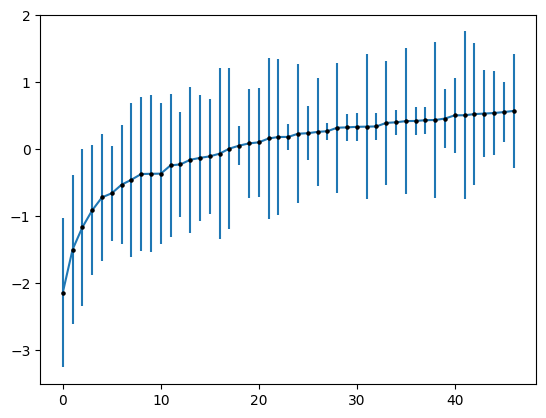

In [60]:
# Optional restart cell: use this only when reopening after taxonomy labelling.
import arviz as az
import birdman.visualization as viz
inference = az.from_netcdf(INFERENCE_LABELED_FILE)
# sanity peek
print(inference.posterior["feature"].values[:10])


# In[ ]:


ax = viz.plot_parameter_estimates(
    inference,
    parameter="beta_var",
    coords={"covariate": "Diet[T.HC]"},
)

In [61]:
# Inspect first again
print(inference.posterior["beta_var"].dims, inference.posterior["beta_var"].shape)

('chain', 'draw', 'covariate', 'feature') (4, 500, 14, 47)


In [62]:
summ = az.summary(
    inference,
    var_names=["beta_var"],
    coords={"covariate": "Diet[T.HC]"}
)
significant_asvs = summ[
    (summ["hdi_3%"] > 0) | (summ["hdi_97%"] < 0)
]
print(significant_asvs)

                                         mean     sd  hdi_3%  hdi_97%  \
beta_var[ASV_1846 | g__Malacoplasma]    0.268  0.129   0.041    0.523   
beta_var[ASV_484 | g__Malacoplasma]     0.432  0.203   0.041    0.792   
beta_var[ASV_1517 | g__Malacoplasma]    0.421  0.204   0.003    0.765   
beta_var[ASV_1650 | g__Staphylococcus] -2.140  1.116  -4.158   -0.026   
beta_var[ASV_2862 | g__Malacoplasma]    0.401  0.188   0.052    0.745   

                                        mcse_mean  mcse_sd  ess_bulk  \
beta_var[ASV_1846 | g__Malacoplasma]        0.003    0.002    2491.0   
beta_var[ASV_484 | g__Malacoplasma]         0.006    0.004    1362.0   
beta_var[ASV_1517 | g__Malacoplasma]        0.006    0.004    1292.0   
beta_var[ASV_1650 | g__Staphylococcus]      0.023    0.024    2484.0   
beta_var[ASV_2862 | g__Malacoplasma]        0.005    0.003    1671.0   

                                        ess_tail  r_hat  
beta_var[ASV_1846 | g__Malacoplasma]      1560.0    1.0  
beta_var[ASV

In [63]:
import arviz as az

# Get a tidy summary for all covariates
az.summary(
    inference, 
    var_names=["beta_var"],       # or whatever your coefficient var is named
    coords={"covariate": [
        "Diet[T.HC]",
        "Day[T.day_02]", "Day[T.day_03]", "Day[T.day_04]", 
        "Day[T.day_10]", "Day[T.day_15]", "Day[T.day_22]",
        "Diet[T.HC]:Day[T.day_02]", "Diet[T.HC]:Day[T.day_03]",
        "Diet[T.HC]:Day[T.day_04]", "Diet[T.HC]:Day[T.day_10]",
        "Diet[T.HC]:Day[T.day_15]", "Diet[T.HC]:Day[T.day_22]"
    ]}
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta_var[Diet[T.HC], ASV_1846 | g__Malacoplasma]",0.268,0.129,0.041,0.523,0.003,0.002,2491.0,1560.0,1.0
"beta_var[Diet[T.HC], ASV_48 | g__Paracoccus]",0.160,1.208,-1.935,2.581,0.024,0.022,2500.0,2035.0,1.0
"beta_var[Diet[T.HC], ASV_124 | c__Clostridia]",0.506,1.250,-1.959,2.713,0.022,0.024,3233.0,1679.0,1.0
"beta_var[Diet[T.HC], ASV_276 | f__Neisseriaceae]",-1.165,1.171,-3.223,1.184,0.022,0.024,2982.0,1495.0,1.0
"beta_var[Diet[T.HC], ASV_338 | g__Malacoplasma]",0.571,0.849,-0.933,2.286,0.019,0.017,2073.0,1560.0,1.0
...,...,...,...,...,...,...,...,...,...
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3018 | g__Brevundimonas]",-3.469,2.311,-7.485,1.059,0.043,0.055,2900.0,1407.0,1.0
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3022 | g__Staphylococcus]",-0.757,1.808,-4.444,2.378,0.033,0.035,3062.0,1622.0,1.0
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3044 | g__Streptococcus]",0.898,1.398,-1.635,3.535,0.028,0.027,2485.0,1833.0,1.0
"beta_var[Diet[T.HC]:Day[T.day_22], ASV_3169 | g__Corynebacterium]",0.089,1.920,-3.628,3.556,0.034,0.043,3197.0,1529.0,1.0


In [64]:
import xarray as xr
import arviz as az

# Posterior for slopes (p-1 covariates) — excludes the Intercept
post_x = inference.posterior["beta_var"]

def sel(term):
    # term must match exactly a label in post_x.coords["covariate"]
    return post_x.sel(covariate=term).reset_coords(drop=True)

days = ["day_01","day_02","day_03","day_04","day_10","day_15","day_22"]

# Baseline contrast (HC - NC) at day_01: just the HC main effect (NC is reference)
delta_base = sel("Diet[T.HC]")

# Contrasts for other days: HC main effect + HC:Day interaction
deltas = {"day_01": delta_base}
for d in days[1:]:
    inter_term = f"Diet[T.HC]:Day[T.{d}]"
    deltas[d] = delta_base + sel(inter_term)

# Stack contrasts over days -> dims: (chain, draw, feature, day)
delta_all = xr.concat([deltas[d] for d in days], dim="day").assign_coords(day=days)

# Summarize (mean, sd, R-hat, ESS, 95% HDI)
summary = az.summary(delta_all, hdi_prob=0.95)
print(summary)

                                                  mean     sd  hdi_2.5%  \
beta_var[day_01, ASV_1846 | g__Malacoplasma]     0.268  0.129     0.017   
beta_var[day_01, ASV_48 | g__Paracoccus]         0.160  1.208    -1.994   
beta_var[day_01, ASV_124 | c__Clostridia]        0.506  1.250    -1.880   
beta_var[day_01, ASV_276 | f__Neisseriaceae]    -1.165  1.171    -3.216   
beta_var[day_01, ASV_338 | g__Malacoplasma]      0.571  0.849    -1.117   
...                                                ...    ...       ...   
beta_var[day_22, ASV_3018 | g__Brevundimonas]   -3.834  2.326    -8.010   
beta_var[day_22, ASV_3022 | g__Staphylococcus]  -0.915  1.748    -4.308   
beta_var[day_22, ASV_3044 | g__Streptococcus]    1.291  1.252    -1.139   
beta_var[day_22, ASV_3169 | g__Corynebacterium] -0.278  1.899    -4.245   
beta_var[day_22, ASV_3234 | g__Lawsonella]       0.973  0.809    -0.648   

                                                 hdi_97.5%  mcse_mean  \
beta_var[day_01, ASV_1846 

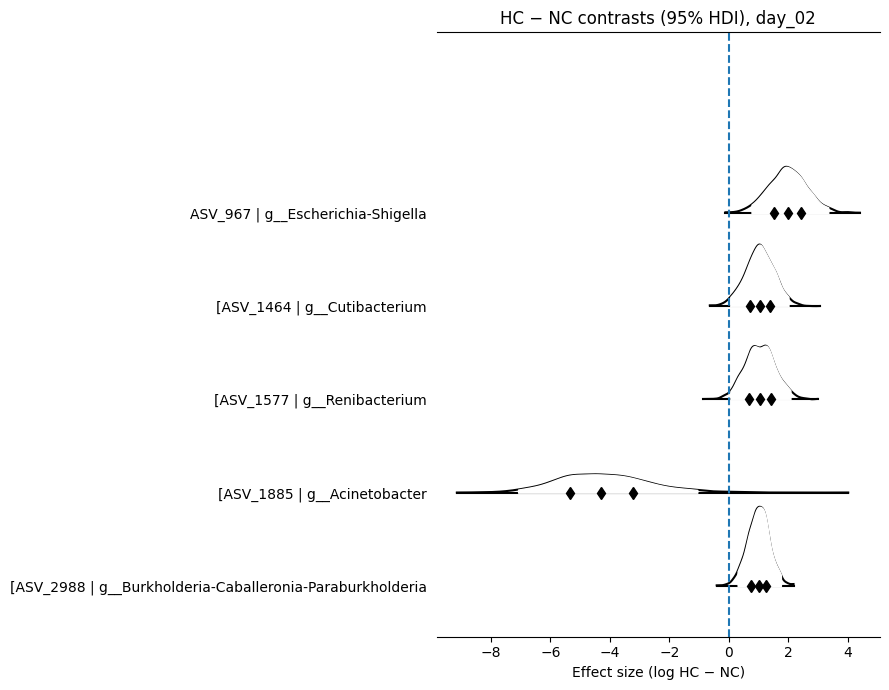

In [66]:
import re
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

day = "day_02"

# summarize contrasts for this day
summ = az.summary(delta_all.sel(day=day), hdi_prob=0.95).rename(columns={"mean":"mean_logFC"})

# keep only HDIs that exclude 0
sig = summ[(summ["hdi_2.5%"] > 0) | (summ["hdi_97.5%"] < 0)].copy()

# extract the feature labels inside brackets
feat_idx = delta_all.coords["feature"].to_index()
sig_features = []
for s in sig.index.astype(str):
    m = re.search(r"\[(.*)\]", s)  # text inside [...]
    if m:
        label = m.group(1)
        if label in feat_idx:
            sig_features.append(label)

if not sig_features:
    raise ValueError("No matching features found after parsing labels. Inspect `summ.index[:5]`.")

# forest plot for those features
to_plot = delta_all.sel(day=day, feature=sig_features).rename("contrast")  # avoid 'beta_x' prefix
axes = az.plot_forest(to_plot,
                      kind='ridgeplot',
                      ridgeplot_truncate=False,
                      ridgeplot_quantiles=[.25, .5, .75],
                      ridgeplot_overlap=0.7,
                      colors='white',
                      figsize=(9, 7),
                      combined=True,
                      hdi_prob=0.95)

# --- put the label-fix RIGHT HERE ---
ax = np.atleast_1d(axes).ravel()[0]
curr = [t.get_text() for t in ax.get_yticklabels()]
# remove the var prefix before '[' and the trailing ']'
clean = [re.sub(r'^[^\[]+\[|\]$', '', s) for s in curr]
# optional: shorten to just ASV ID
# clean = [c.split(" | ", 1)[0] for c in clean]
ax.set_yticklabels(clean)

plt.axvline(0, linestyle="--")
plt.xlabel("Effect size (log HC − NC)")
plt.title(f"HC − NC contrasts (95% HDI), {day}")
plt.tight_layout()
plt.show()

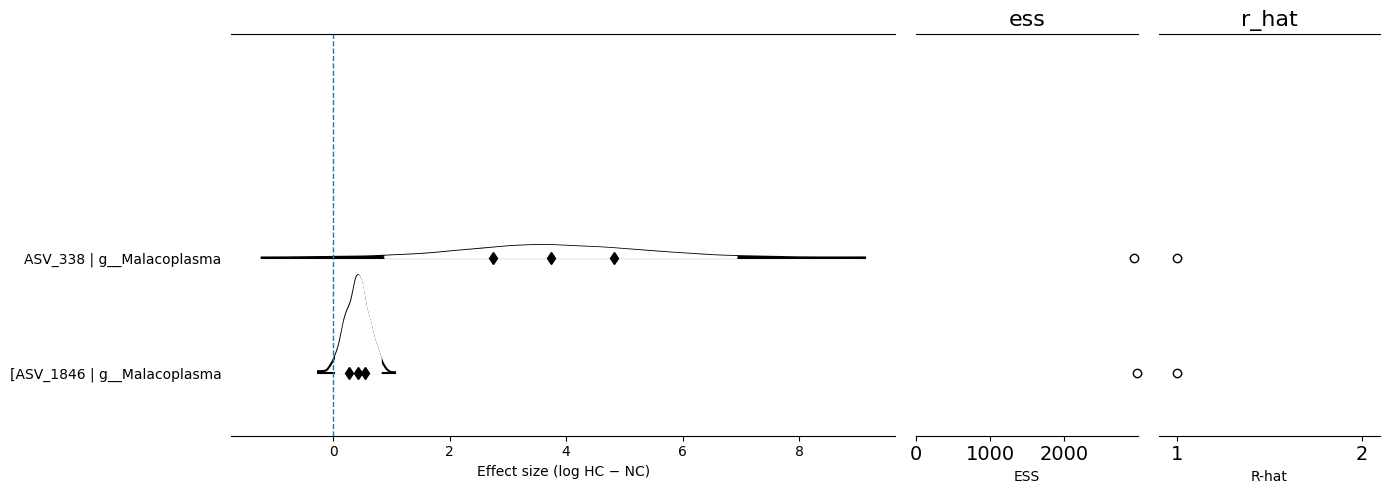

In [65]:
import re
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# ---------- SETTINGS ----------
day = "day_22"
hdi_prob = 0.95          # set to 0.975 if you want stricter intervals
kind = "ridgeplot"       # "ridgeplot" for ridges, anything else for bar-style
top_n = 40               # None for all, or limit to top effects
ridge_kwargs = dict(     # only used when kind == "ridgeplot"
    ridgeplot_truncate=False,
    ridgeplot_quantiles=[0.25, 0.5, 0.75],   # median line only; use [.25,.5,.75] if you like
    ridgeplot_overlap=0.7,
    colors='white'
)

# ---------- 1) Summarize contrasts for this day ----------
summ = az.summary(delta_all.sel(day=day), hdi_prob=hdi_prob).rename(columns={"mean":"mean_logFC"})

# find the two HDI columns (works for 2.5/97.5 or any)
hdi_cols = [c for c in summ.columns if c.startswith("hdi_")]
if len(hdi_cols) < 2:
    raise RuntimeError(f"HDI columns not found in summary: {summ.columns.tolist()}")

# sort by percentile value (e.g., ['hdi_2.5%', 'hdi_97.5%'])
low_col, high_col = sorted(hdi_cols, key=lambda c: float(c.split("_")[1].strip("%")))

# keep only HDIs that exclude 0
sig = summ[(summ[low_col] > 0) | (summ[high_col] < 0)].copy()
if sig.empty:
    raise ValueError(f"No ASVs with {int(hdi_prob*100)}% HDI excluding 0 for {day}.")

# order by absolute effect size and optionally limit
sig["abs_effect"] = sig["mean_logFC"].abs()
sig = sig.sort_values("abs_effect", ascending=False)
if top_n is not None and len(sig) > top_n:
    sig = sig.iloc[:top_n]

# ---------- 2) Parse feature labels from the index ----------
feat_idx = delta_all.coords["feature"].to_index()
sig_features = []
for s in sig.index.astype(str):
    m = re.search(r"\[(.*)\]", s)  # grabs text inside [...]
    if m:
        label = m.group(1)
        if label in feat_idx:
            sig_features.append(label)

if not sig_features:
    raise ValueError("Parsed 0 matching features. Inspect `summ.index[:5]` to see labels.")

# ---------- 3) Forest / ridge plot (CALL ONCE) ----------
to_plot = delta_all.sel(day=day, feature=sig_features).rename("contrast")  # stay on log scale

plt.close("all")  # ensure a fresh figure
plot_kwargs = dict(combined=True, hdi_prob=hdi_prob, ess=True, r_hat=True)

if kind == "ridgeplot":
    axes = az.plot_forest(to_plot, kind="ridgeplot", **plot_kwargs, **ridge_kwargs)
else:
    axes = az.plot_forest(to_plot, **plot_kwargs)

axes_arr = np.atleast_1d(axes).ravel()

# 1) label + zero line ONLY on the main (leftmost) axis
main_ax = axes_arr[0]
main_ax.axvline(0, linestyle="--", linewidth=1)
main_ax.set_xlabel("Effect size (log HC − NC)")

# 2) give sensible labels to the metric panels (if present)
if len(axes_arr) >= 2:
    axes_arr[1].set_xlabel("ESS")
if len(axes_arr) >= 3:
    axes_arr[2].set_xlabel("R-hat")

# 3) clean the first y-tick prefix on the main axis
curr = [t.get_text() for t in main_ax.get_yticklabels()]
if curr:
    clean = [re.sub(r'^[^\[]+\[|\]$', '', s) for s in curr]  # remove 'contrast[' ... ']'
    # optional shorter labels: clean = [c.split(" | ", 1)[0] for c in clean]
    main_ax.set_yticklabels(clean)

plt.tight_layout()
plt.show()